# Notebook Visualisasi Skripsi — Gambar & Tabel untuk Bab III

**Klasifikasi Komentar Publik Layanan Digital Pemerintah dengan XGBoost & IndoBERT**

Notebook ini menghasilkan **seluruh gambar dan grafik** yang direkomendasikan untuk skripsi, **berbasis data & model asli** dari project Anda (bukan angka hardcoded).

---

### ⚙️ Cara Pakai
1. Letakkan notebook ini di folder utama project Anda (`xgboost_indobert_method` / `1. MAIN`).
2. Sesuaikan `BASE_DIR` di Sel 1 bila perlu.
3. Jalankan sel berurutan (Run All).
4. Semua gambar otomatis tersimpan ke folder `output_visualisasi/` dengan DPI 300 (siap tempel ke Word).

### 📋 Daftar Output
| No | Nama File | Untuk Gambar/Tabel Skripsi |
|----|-----------|----------------------------|
| 1 | `dist_kelas_labeling.png` | Distribusi Kelas Hasil Labeling |
| 2 | `dist_kelas_per_layanan.png` | Distribusi Kelas per Layanan (BPJS/Coretax/MBG) |
| 3 | `dist_confidence_band.png` | Distribusi Confidence Pseudo-Label per Band |
| 4 | `dist_panjang_komentar.png` | Distribusi Panjang Komentar |
| 5 | `wordcloud_per_kelas.png` | WordCloud per Kelas Sentimen |
| 6 | `dist_train_test.png` | Perbandingan Data Train vs Test (3 skenario) |
| 7 | `chi2_top_features.png` | Top Fitur Chi-Square |
| 8 | `feature_importance_xgb.png` | Feature Importance XGBoost |
| 9 | `cm_semua_model.png` | Confusion Matrix Semua Model |
| 10 | `perbandingan_metrik.png` | Perbandingan Akurasi & Macro-F1 Semua Model |
| 11 | `perbandingan_f1_per_kelas.png` | Perbandingan F1 per Kelas Antar Model |
| 12 | `macro_vs_weighted.png` | Macro Avg vs Weighted Avg |
| 13 | `dampak_data_terhadap_f1.png` | Dampak Volume Data terhadap Macro-F1 |
| 14 | `tabel_rekap_metrik.csv` | Tabel Rekapitulasi Metrik Lintas Skenario |


## Sel 1 — Setup, Path, dan Tema Visual

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ============================================================
# SESUAIKAN PATH INI DENGAN FOLDER PROJECT ANDA
# ============================================================
BASE_DIR = r'C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method'
# Fallback jika struktur folder berbeda:
if not os.path.isdir(BASE_DIR):
    BASE_DIR = os.getcwd()
    print(f"[info] BASE_DIR otomatis = {BASE_DIR}")

OUT_DIR = os.path.join(BASE_DIR, 'output_visualisasi')
os.makedirs(OUT_DIR, exist_ok=True)

# Tema visual konsisten
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi'      : 110,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 13,
})

# Palet warna 3 kelas (konsisten di semua grafik)
CMAP = {'keluhan': '#EF4444', 'saran': '#3B82F6', 'pujian': '#22C55E'}
KELAS = ['keluhan', 'saran', 'pujian']

def simpan(fig, nama):
    path = os.path.join(OUT_DIR, nama)
    fig.savefig(path)
    print(f"  ✅ Tersimpan: {path}")

print("Setup selesai. Output ->", OUT_DIR)

Setup selesai. Output -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi


## Sel 2 — Memuat Dataset & Helper Pencari File

Notebook mencoba beberapa kemungkinan nama file secara otomatis sehingga tetap jalan walau penamaan sedikit berbeda.

In [2]:
def cari_file(*kandidat):
    """Cari file pertama yang ada dari beberapa kemungkinan nama/lokasi."""
    for nama in kandidat:
        p = nama if os.path.isabs(nama) else os.path.join(BASE_DIR, nama)
        if os.path.exists(p):
            return p
    # cari rekursif di subfolder
    for nama in kandidat:
        base = os.path.basename(nama)
        for root, _, files in os.walk(BASE_DIR):
            if base in files:
                return os.path.join(root, base)
    return None

# --- Data berlabel manual (punya kolom label_pks) ---
path_label = cari_file('data_labeling.csv', '03_data_labelling/data_labeling.csv',
                       'labelled_data_final.csv')
df_label = pd.read_csv(path_label) if path_label else None
print("Data labeling:", path_label, "| baris:", len(df_label) if df_label is not None else "TIDAK ADA")

# --- Data hasil preprocessing (gabungan manual + pseudo-label) ---
path_prep = cari_file('data_preprocessing_4.0.csv', 'data_preprocessing_3.0.csv',
                      'data_preprocessed_v2.csv', 'data_preprocessing_2.0.csv')
df_prep = pd.read_csv(path_prep) if path_prep else None
print("Data preprocessing:", path_prep, "| baris:", len(df_prep) if df_prep is not None else "TIDAK ADA")

# --- Data hasil cleaning (untuk distribusi awal) ---
path_clean = cari_file('cleaned_data_baru.csv', 'cleaned_data.csv',
                       '02_data_cleaning/cleaned_data_v2.csv')
df_clean = pd.read_csv(path_clean) if path_clean else None
print("Data cleaning:", path_clean, "| baris:", len(df_clean) if df_clean is not None else "TIDAK ADA")

# Deteksi nama kolom label & teks secara otomatis
def deteksi_kolom(df, kandidat):
    if df is None: return None
    for k in kandidat:
        if k in df.columns: return k
    return None

KOL_LABEL = deteksi_kolom(df_label, ['label_pks','label','klasifikasi','sentimen'])
KOL_TEKS  = deteksi_kolom(df_label, ['text','komentar','teks','clean_text'])
print(f"\nKolom label terdeteksi: '{KOL_LABEL}' | Kolom teks: '{KOL_TEKS}'")

Data labeling: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\data_labeling.csv | baris: 18534
Data preprocessing: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\data_preprocessing_4.0.csv | baris: 56315
Data cleaning: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\cleaned_data_baru.csv | baris: 61629

Kolom label terdeteksi: 'label_pks' | Kolom teks: 'text'


## Sel 3 — Gambar 1: Distribusi Kelas Hasil Labeling

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\dist_kelas_labeling.png


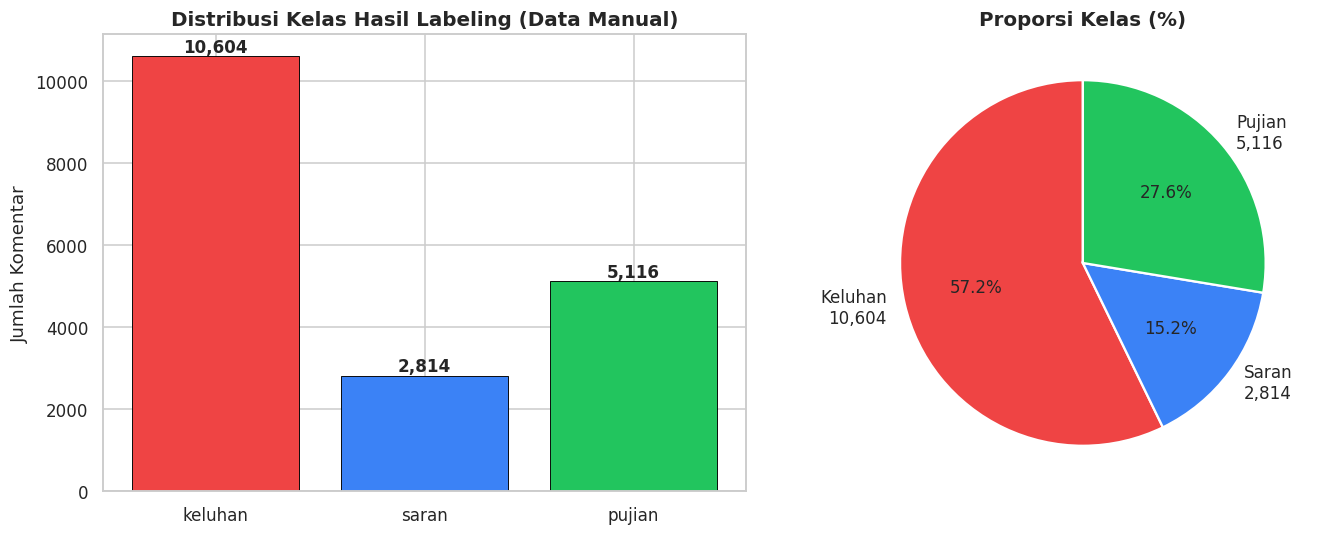


Distribusi: {'keluhan': np.int64(10604), 'saran': np.int64(2814), 'pujian': np.int64(5116)}


In [3]:
if df_label is not None and KOL_LABEL:
    counts = df_label[KOL_LABEL].value_counts().reindex(KELAS).fillna(0).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart
    bars = axes[0].bar(counts.index, counts.values,
                       color=[CMAP[k] for k in counts.index], edgecolor='black', linewidth=0.6)
    axes[0].set_title('Distribusi Kelas Hasil Labeling (Data Manual)')
    axes[0].set_ylabel('Jumlah Komentar')
    for b, v in zip(bars, counts.values):
        axes[0].text(b.get_x()+b.get_width()/2, v+max(counts.values)*0.01,
                     f'{v:,}', ha='center', fontweight='bold')

    # Pie chart
    axes[1].pie(counts.values, labels=[f'{k.title()}\n{v:,}' for k,v in counts.items()],
                colors=[CMAP[k] for k in counts.index], autopct='%1.1f%%',
                startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[1].set_title('Proporsi Kelas (%)')

    plt.tight_layout()
    simpan(fig, 'dist_kelas_labeling.png')
    plt.show()
    print("\nDistribusi:", dict(counts))
else:
    print("⚠️ Data label / kolom label tidak ditemukan.")

## Sel 4 — Gambar 2: Distribusi Kelas per Layanan (BPJS / Coretax / MBG)

Layanan dideteksi dari kolom `source_file` (mengandung kata kunci layanan).

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\dist_kelas_per_layanan.png


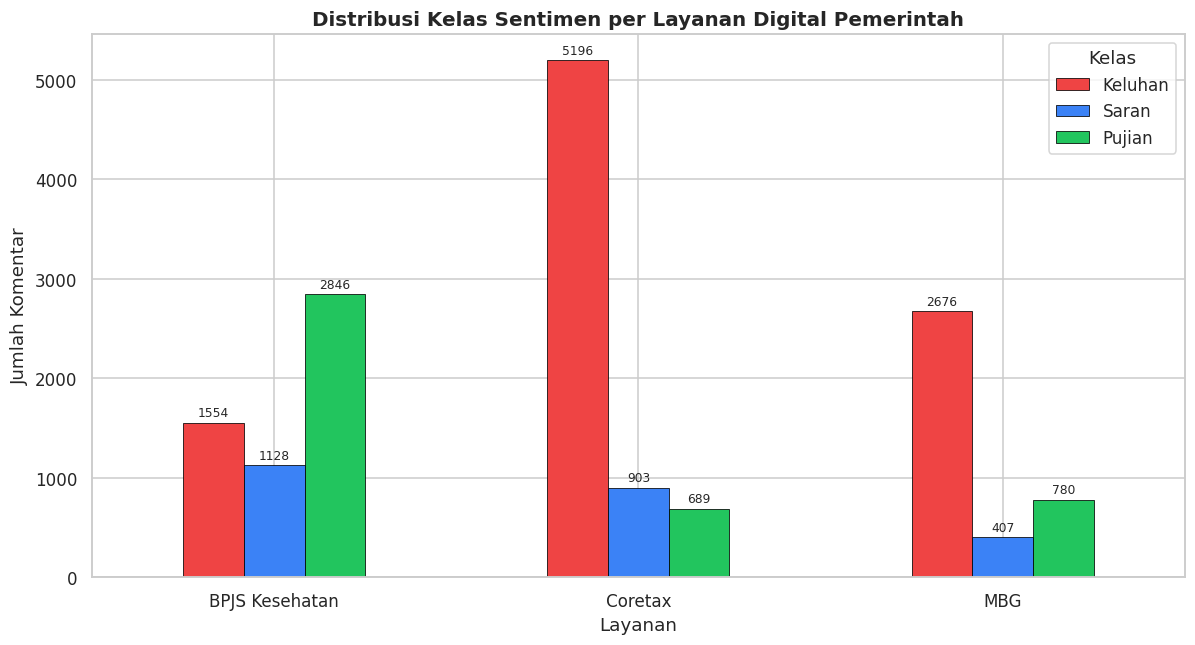

label_pks       keluhan  saran  pujian
layanan                               
BPJS Kesehatan     1554   1128    2846
Coretax            5196    903     689
MBG                2676    407     780


In [4]:
def deteksi_layanan(row):
    src = str(row.get('source_file','')).lower() + ' ' + str(row.get('postUrl','')).lower()
    if any(k in src for k in ['bpjs','jkn','kesehatan']): return 'BPJS Kesehatan'
    if any(k in src for k in ['coretax','pajak','djp','ditjenpajak']): return 'Coretax'
    if any(k in src for k in ['mbg','gizi','makan','bgn']): return 'MBG'
    return 'Lainnya'

if df_label is not None and KOL_LABEL and 'source_file' in df_label.columns:
    tmp = df_label.copy()
    tmp['layanan'] = tmp.apply(deteksi_layanan, axis=1)
    tmp = tmp[tmp['layanan'] != 'Lainnya']

    pivot = tmp.groupby(['layanan', KOL_LABEL]).size().unstack(fill_value=0)
    pivot = pivot.reindex(columns=KELAS, fill_value=0)

    fig, ax = plt.subplots(figsize=(11, 6))
    pivot.plot(kind='bar', ax=ax, color=[CMAP[k] for k in pivot.columns],
               edgecolor='black', linewidth=0.5)
    ax.set_title('Distribusi Kelas Sentimen per Layanan Digital Pemerintah')
    ax.set_xlabel('Layanan'); ax.set_ylabel('Jumlah Komentar')
    ax.legend(title='Kelas', labels=[k.title() for k in pivot.columns])
    plt.xticks(rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%d', fontsize=8, padding=2)
    plt.tight_layout()
    simpan(fig, 'dist_kelas_per_layanan.png')
    plt.show()
    print(pivot)
else:
    print("⚠️ Kolom source_file tidak tersedia untuk deteksi layanan.")

## Sel 5 — Gambar 3: Distribusi Confidence Pseudo-Label per Band

Membaca kolom confidence dari data preprocessing/pseudo-label. Band: Rendah (≤0.70), Sedang (0.70–0.85), Tinggi (≥0.85).

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\dist_confidence_band.png


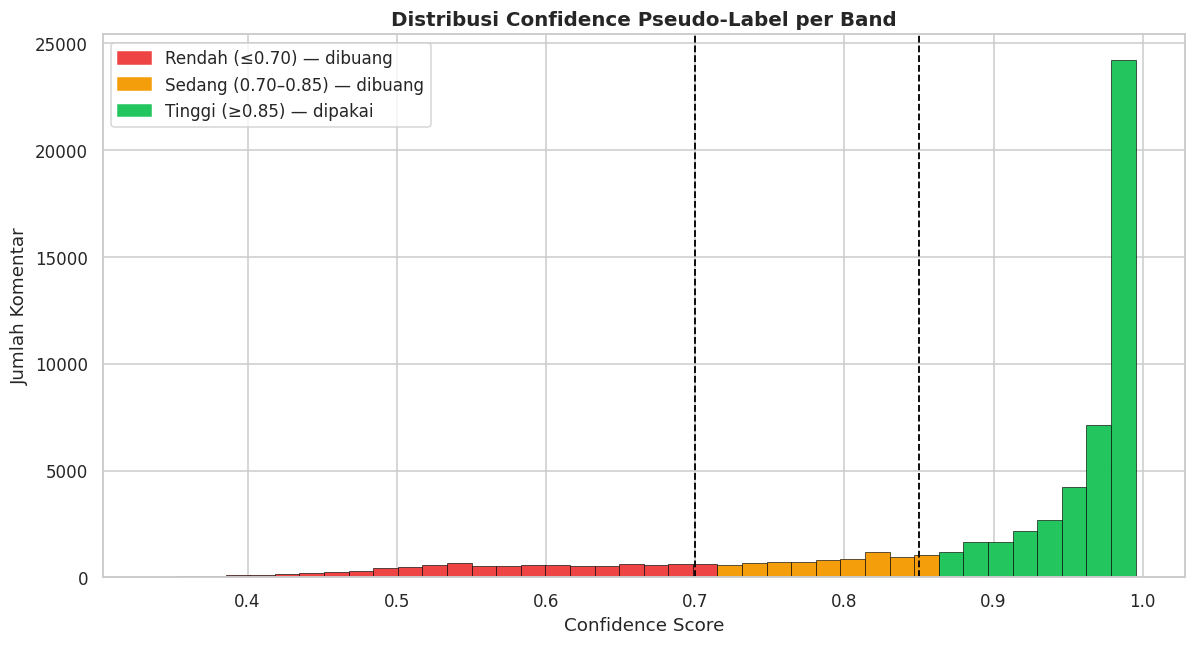

Band Rendah: 8,511 | Sedang: 7,299 | Tinggi: 45,819


In [5]:
# Cari file pseudo-label dengan kolom confidence
path_pseudo = cari_file('labelled_data_baru.csv','data_preprocessing_4.0.csv',
                        'spot_check_200.csv','data_preprocessed_v2.csv')
df_conf = pd.read_csv(path_pseudo) if path_pseudo else None

kol_conf = None
if df_conf is not None:
    for k in ['confidence','confidence_score','conf','prob','probability','skor']:
        if k in df_conf.columns:
            kol_conf = k; break

if df_conf is not None and kol_conf:
    conf = pd.to_numeric(df_conf[kol_conf], errors='coerce').dropna()
    # normalisasi bila 0-100
    if conf.max() > 1.5: conf = conf / 100.0

    fig, ax = plt.subplots(figsize=(11, 6))
    n, bins, patches = ax.hist(conf, bins=40, edgecolor='black', linewidth=0.4)
    # warnai per band
    for patch, left in zip(patches, bins[:-1]):
        if left < 0.70:   patch.set_facecolor('#EF4444')
        elif left < 0.85: patch.set_facecolor('#F59E0B')
        else:             patch.set_facecolor('#22C55E')
    ax.axvline(0.70, color='black', ls='--', lw=1.2)
    ax.axvline(0.85, color='black', ls='--', lw=1.2)
    ax.set_title('Distribusi Confidence Pseudo-Label per Band')
    ax.set_xlabel('Confidence Score'); ax.set_ylabel('Jumlah Komentar')
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#EF4444', label='Rendah (≤0.70) — dibuang'),
        Patch(color='#F59E0B', label='Sedang (0.70–0.85) — dibuang'),
        Patch(color='#22C55E', label='Tinggi (≥0.85) — dipakai'),
    ])
    plt.tight_layout()
    simpan(fig, 'dist_confidence_band.png')
    plt.show()

    rendah = (conf<=0.70).sum(); sedang=((conf>0.70)&(conf<0.85)).sum(); tinggi=(conf>=0.85).sum()
    print(f"Band Rendah: {rendah:,} | Sedang: {sedang:,} | Tinggi: {tinggi:,}")
else:
    print("⚠️ Kolom confidence tidak ditemukan. Lewati grafik ini atau sesuaikan nama kolom.")
    if df_conf is not None: print("Kolom tersedia:", list(df_conf.columns))

## Sel 6 — Gambar 4: Distribusi Panjang Komentar per Kelas

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\dist_panjang_komentar.png


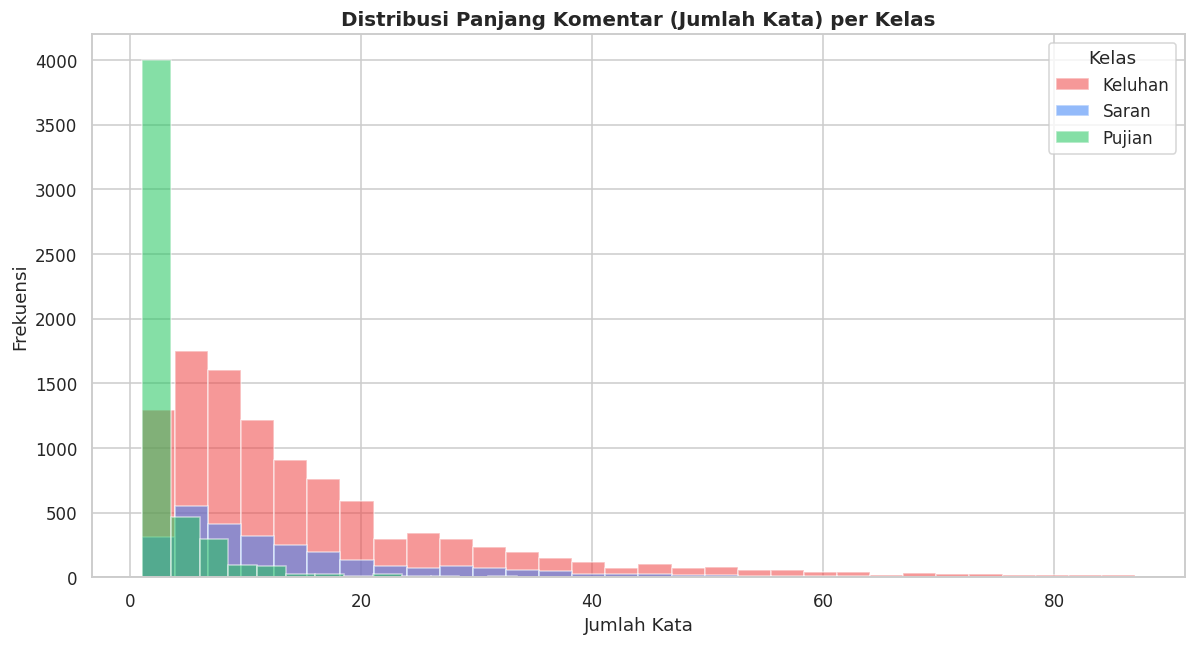

                mean   50%   max
label_pks                       
keluhan    15.464518  11.0  87.0
pujian      3.004500   1.0  76.0
saran      15.079051  11.0  87.0


In [6]:
if df_label is not None and KOL_TEKS and KOL_LABEL:
    tmp = df_label.dropna(subset=[KOL_TEKS]).copy()
    tmp['n_kata'] = tmp[KOL_TEKS].astype(str).str.split().str.len()
    tmp = tmp[tmp['n_kata'] <= tmp['n_kata'].quantile(0.99)]  # buang outlier ekstrem

    fig, ax = plt.subplots(figsize=(11, 6))
    for k in KELAS:
        sub = tmp[tmp[KOL_LABEL]==k]['n_kata']
        if len(sub):
            ax.hist(sub, bins=30, alpha=0.55, label=k.title(), color=CMAP[k])
    ax.set_title('Distribusi Panjang Komentar (Jumlah Kata) per Kelas')
    ax.set_xlabel('Jumlah Kata'); ax.set_ylabel('Frekuensi')
    ax.legend(title='Kelas')
    plt.tight_layout()
    simpan(fig, 'dist_panjang_komentar.png')
    plt.show()
    print(tmp.groupby(KOL_LABEL)['n_kata'].describe()[['mean','50%','max']])
else:
    print("⚠️ Data teks/label tidak tersedia.")

## Sel 7 — Gambar 5: WordCloud per Kelas Sentimen

Membutuhkan `pip install wordcloud`. Pakai kolom teks hasil preprocessing bila ada (lebih bersih).

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\wordcloud_per_kelas.png


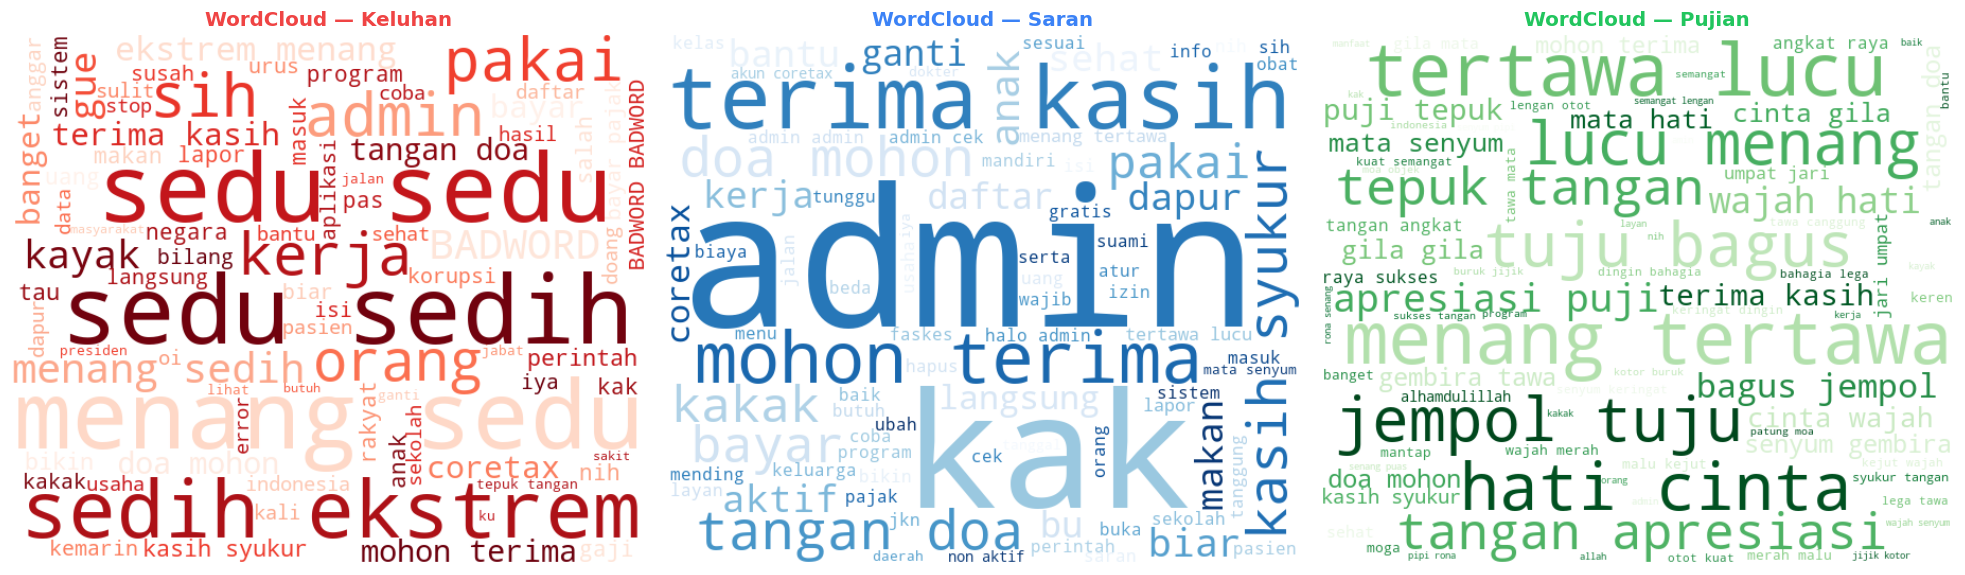

In [7]:
try:
    from wordcloud import WordCloud
    # pilih kolom teks terbersih
    src_df = df_prep if (df_prep is not None) else df_label
    kol_t = None
    for k in ['clean_text','text_preprocessed','final_text','text_clean','stemming','text']:
        if src_df is not None and k in src_df.columns:
            kol_t = k; break
    kol_l = deteksi_kolom(src_df, ['label_pks','label','klasifikasi','sentimen'])

    if src_df is not None and kol_t and kol_l:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for ax, k in zip(axes, KELAS):
            teks = ' '.join(src_df[src_df[kol_l]==k][kol_t].dropna().astype(str).tolist())
            if not teks.strip():
                ax.axis('off'); ax.set_title(f'{k.title()} (kosong)'); continue
            wc = WordCloud(width=600, height=500, background_color='white',
                           colormap='Reds' if k=='keluhan' else ('Blues' if k=='saran' else 'Greens'),
                           max_words=80).generate(teks)
            ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
            ax.set_title(f'WordCloud — {k.title()}', color=CMAP[k])
        plt.tight_layout()
        simpan(fig, 'wordcloud_per_kelas.png')
        plt.show()
    else:
        print("⚠️ Kolom teks/label untuk wordcloud tidak ditemukan.")
except ImportError:
    print("⚠️ Install dulu: pip install wordcloud")

## Sel 8 — Gambar 6: Perbandingan Data Train vs Test (3 Skenario)

Membaca file train/test final untuk setiap skenario. Sesuaikan nama file bila perlu.

  ✅ Tersimpan: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\output_visualisasi\dist_train_test.png


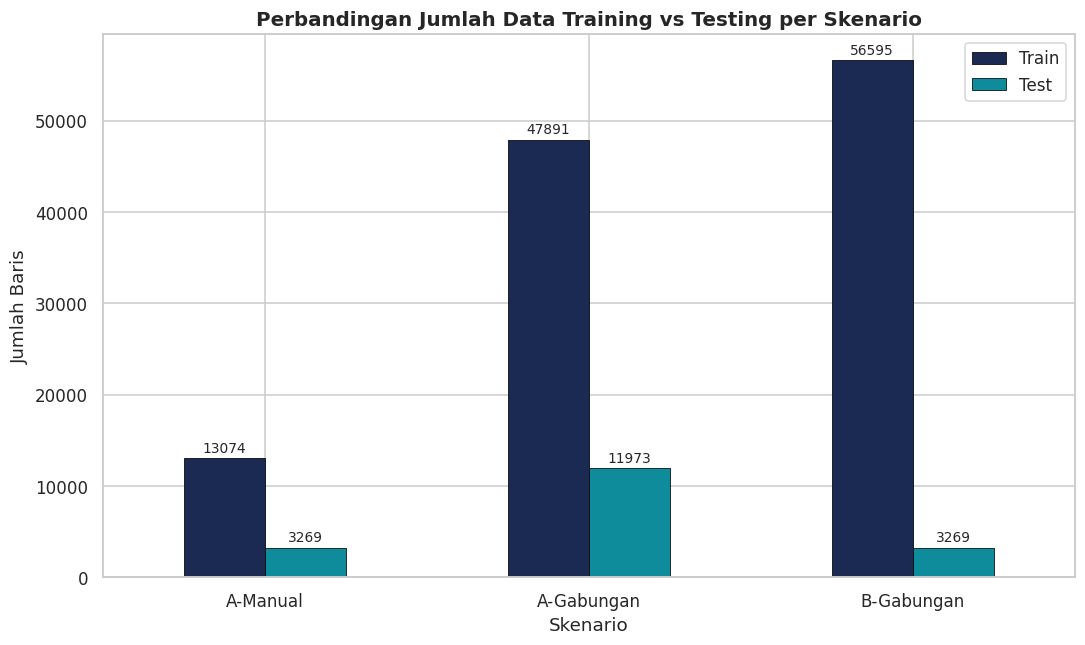

            Train   Test
Skenario                
A-Manual    13074   3269
A-Gabungan  47891  11973
B-Gabungan  56595   3269


In [9]:
skenario = {
    'A-Manual'  : ('v2b_manual_train.csv', 'v2b_manual_test.csv'),
    'A-Gabungan': ('v2b_agab_train.csv', 'v2b_agab_test.csv'),
    'B-Gabungan': ('v2b_bgab_train.csv', 'v2b_bgab_test.csv'),
}
rows = []
for nama, (ftr, fte) in skenario.items():
    ptr, pte = cari_file(ftr), cari_file(fte)
    ntr = len(pd.read_csv(ptr)) if ptr else None
    nte = len(pd.read_csv(pte)) if pte else None
    if ntr or nte:
        rows.append({'Skenario':nama, 'Train':ntr or 0, 'Test':nte or 0})

if rows:
    dfs = pd.DataFrame(rows).set_index('Skenario')
    fig, ax = plt.subplots(figsize=(10, 6))
    dfs.plot(kind='bar', ax=ax, color=['#1B2A52','#0E8C9B'], edgecolor='black', linewidth=0.5)
    ax.set_title('Perbandingan Jumlah Data Training vs Testing per Skenario')
    ax.set_ylabel('Jumlah Baris'); plt.xticks(rotation=0)
    for c in ax.containers: ax.bar_label(c, fmt='%d', fontsize=9, padding=2)
    plt.tight_layout()
    simpan(fig, 'dist_train_test.png')
    plt.show()
    print(dfs)
else:
    print("⚠️ File train/test tidak ditemukan. Sesuaikan dict 'skenario' dengan nama file Anda.")

## Sel 9 — Gambar 7: Top Fitur Chi-Square

Membaca file skor Chi-Square yang sudah Anda simpan (`hasil_skor_chi2_lengkap_*.csv`).

In [10]:
path_chi2 = cari_file('hasil_skor_chi2_lengkap_4.0.csv','hasil_skor_chi2_lengkap_3.0.csv')
if path_chi2:
    dfc = pd.read_csv(path_chi2)
    # deteksi kolom fitur & skor
    kol_fitur = next((c for c in dfc.columns if c.lower() in ['fitur','feature','term','kata','token']), dfc.columns[0])
    kol_skor  = next((c for c in dfc.columns if 'chi' in c.lower() or 'score' in c.lower() or 'skor' in c.lower()), dfc.columns[1])
    top = dfc.sort_values(kol_skor, ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top[kol_fitur][::-1], top[kol_skor][::-1], color='#0E8C9B', edgecolor='black', linewidth=0.4)
    ax.set_title('Top 20 Fitur Berdasarkan Skor Chi-Square')
    ax.set_xlabel('Skor Chi-Square')
    plt.tight_layout()
    simpan(fig, 'chi2_top_features.png')
    plt.show()
    print(top[[kol_fitur, kol_skor]].head(10))
else:
    print("⚠️ File skor Chi-Square tidak ditemukan.")

⚠️ File skor Chi-Square tidak ditemukan.


## Sel 10 — Gambar 8: Feature Importance XGBoost

Memuat model XGBoost (.pkl) + TF-IDF vectorizer + selector untuk memetakan importance ke nama fitur asli.

In [ ]:
import pickle, joblib

def load_pkl(*kandidat):
    p = cari_file(*kandidat)
    if not p: return None
    try:    return joblib.load(p)
    except: 
        try: return pickle.load(open(p,'rb'))
        except: return None

model_xgb = load_pkl('model_xgboost_tuned_4.0.pkl','model_xgboost_tuned_3.0.pkl','model_xgboost_4.0.pkl')
tfidf     = load_pkl('tfidf_model_rev_4.0.pkl','tfidf_model_4.0.pkl','tfidf_model_rev_3.0.pkl','tfidf_model_3.0.pkl')
selector  = load_pkl('selector_chi2_rev_4.0.pkl','selector_chi2_4.0.pkl','selector_chi2_rev_3.0.pkl','selector_chi2_3.0.pkl')

if model_xgb is not None and tfidf is not None and selector is not None:
    fitur_semua = np.array(tfidf.get_feature_names_out())
    fitur_terpilih = fitur_semua[selector.get_support()]
    importance = model_xgb.feature_importances_

    n = min(len(fitur_terpilih), len(importance))
    imp_df = pd.DataFrame({'fitur': fitur_terpilih[:n], 'importance': importance[:n]})
    top = imp_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['fitur'][::-1], top['importance'][::-1], color='#7C3AED', edgecolor='black', linewidth=0.4)
    ax.set_title('Top 20 Feature Importance — XGBoost (Tuned)')
    ax.set_xlabel('Importance (Gain)')
    plt.tight_layout()
    simpan(fig, 'feature_importance_xgb.png')
    plt.show()
    print(top.head(10))
else:
    print("⚠️ Model/TF-IDF/selector tidak lengkap. Pastikan ketiga .pkl tersedia.")

## Sel 11 — Gambar 9: Confusion Matrix Semua Model

**Pendekatan apple-to-apple:** semua confusion matrix dihitung pada **test set yang sama** (skenario B-Gabungan, 3.194 baris) agar perbandingan adil. 

Notebook memuat prediksi dari file `y_pred_*.csv` bila Anda sudah menyimpannya, atau menghitung ulang dari model + data test.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from scipy import sparse

# === Helper memuat X_test, y_test untuk model TF-IDF ===
def load_xy_tfidf(npz_name, test_csv):
    Xp = cari_file(npz_name)
    tp = cari_file(test_csv)
    X = sparse.load_npz(Xp) if Xp else None
    y = None
    if tp:
        dft = pd.read_csv(tp)
        kl = deteksi_kolom(dft, ['label_pks','label','klasifikasi','y','target'])
        if kl:
            m = {'keluhan':0,'saran':1,'pujian':2}
            y = dft[kl].map(lambda v: m.get(str(v).lower(), v)).values
    return X, y

# Definisi model yang akan dievaluasi (sesuaikan path bila perlu)
# Untuk model TF-IDF: butuh X_test_selected + model pkl
# Untuk IndoBERT: gunakan prediksi tersimpan (y_pred) bila ada
hasil_prediksi = {}   # nama_model -> (y_true, y_pred)

# --- Model TF-IDF (LR / XGB) pada skenario gabungan ---
X_te, y_te = load_xy_tfidf('X_test_selected_4.0.npz', 'data_test_final_4.0.csv')
for nama, pkl in [
    ('XGBoost Tuned', 'model_xgboost_tuned_4.0.pkl'),
    ('Logistic Regression', 'model_lr_4.0.pkl'),
]:
    mdl = load_pkl(pkl)
    if mdl is not None and X_te is not None and y_te is not None:
        yp = mdl.predict(X_te)
        hasil_prediksi[nama] = (np.array(y_te), np.array(yp))

# --- IndoBERT: muat prediksi tersimpan bila ada ---
for nama, fpred in [('IndoBERT', 'y_pred_indobert_bgab.csv')]:
    pp = cari_file(fpred)
    if pp:
        dp = pd.read_csv(pp)
        if {'y_true','y_pred'}.issubset(dp.columns):
            hasil_prediksi[nama] = (dp['y_true'].values, dp['y_pred'].values)

print("Model dengan prediksi tersedia:", list(hasil_prediksi.keys()))
print("Jika kosong, lihat Sel 11b untuk template menyimpan y_pred dari notebook training Anda.")

In [ ]:
# Plot confusion matrix untuk semua model yang tersedia
if hasil_prediksi:
    n = len(hasil_prediksi)
    fig, axes = plt.subplots(1, n, figsize=(5.5*n, 5))
    if n == 1: axes = [axes]
    for ax, (nama, (yt, yp)) in zip(axes, hasil_prediksi.items()):
        cm = confusion_matrix(yt, yp, labels=[0,1,2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=KELAS, yticklabels=KELAS, cbar=False,
                    linewidths=0.5, linecolor='gray')
        acc = accuracy_score(yt, yp); f1m = f1_score(yt, yp, average='macro')
        ax.set_title(f'{nama}\nAcc={acc:.2%} | Macro-F1={f1m:.3f}')
        ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    plt.tight_layout()
    simpan(fig, 'cm_semua_model.png')
    plt.show()
else:
    print("⚠️ Belum ada prediksi. Jalankan training dulu atau simpan y_pred (lihat Sel 11b).")

### Sel 11b — (Opsional) Template Menyimpan Prediksi dari Notebook Training

Tempelkan potongan ini di **akhir notebook training** masing-masing model untuk menyimpan prediksi, lalu notebook visualisasi ini otomatis membacanya.

```python
# Setelah Anda punya y_true (label asli test) dan y_pred (prediksi model):
import pandas as pd
pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).to_csv(
    'y_pred_indobert_bgab.csv', index=False)   # ganti nama per model
```


## Sel 12 — Gambar 10–12 + Tabel: Rekapitulasi Metrik Semua Model

Menghitung Accuracy, Macro-F1, dan F1 per kelas dari prediksi yang tersedia, lalu membuat 3 grafik perbandingan + 1 tabel CSV.

In [ ]:
if hasil_prediksi:
    rekap = []
    for nama, (yt, yp) in hasil_prediksi.items():
        rep = classification_report(yt, yp, labels=[0,1,2],
                                    target_names=KELAS, output_dict=True, zero_division=0)
        rekap.append({
            'Model'      : nama,
            'Accuracy'   : rep['accuracy'],
            'Macro-F1'   : rep['macro avg']['f1-score'],
            'Weighted-F1': rep['weighted avg']['f1-score'],
            'F1-Keluhan' : rep['keluhan']['f1-score'],
            'F1-Saran'   : rep['saran']['f1-score'],
            'F1-Pujian'  : rep['pujian']['f1-score'],
        })
    df_rekap = pd.DataFrame(rekap).set_index('Model')
    df_rekap.to_csv(os.path.join(OUT_DIR, 'tabel_rekap_metrik.csv'))
    print("✅ Tabel rekap disimpan -> tabel_rekap_metrik.csv\n")
    display(df_rekap.style.format('{:.4f}').background_gradient(cmap='Greens'))

    # --- Gambar 10: Akurasi & Macro-F1 ---
    fig, ax = plt.subplots(figsize=(11, 6))
    df_rekap[['Accuracy','Macro-F1']].plot(kind='bar', ax=ax,
        color=['#1B2A52','#0E8C9B'], edgecolor='black', linewidth=0.5)
    ax.set_title('Perbandingan Akurasi & Macro-F1 Antar Model')
    ax.set_ylabel('Skor'); ax.set_ylim(0,1); plt.xticks(rotation=15)
    for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
    plt.tight_layout(); simpan(fig, 'perbandingan_metrik.png'); plt.show()

    # --- Gambar 11: F1 per kelas ---
    fig, ax = plt.subplots(figsize=(11, 6))
    df_rekap[['F1-Keluhan','F1-Saran','F1-Pujian']].plot(kind='bar', ax=ax,
        color=[CMAP['keluhan'],CMAP['saran'],CMAP['pujian']], edgecolor='black', linewidth=0.5)
    ax.set_title('Perbandingan F1-Score per Kelas Antar Model')
    ax.set_ylabel('F1-Score'); ax.set_ylim(0,1); plt.xticks(rotation=15)
    ax.legend(labels=['Keluhan','Saran','Pujian'])
    for c in ax.containers: ax.bar_label(c, fmt='%.2f', fontsize=7, padding=2)
    plt.tight_layout(); simpan(fig, 'perbandingan_f1_per_kelas.png'); plt.show()

    # --- Gambar 12: Macro vs Weighted ---
    fig, ax = plt.subplots(figsize=(11, 6))
    df_rekap[['Macro-F1','Weighted-F1']].plot(kind='bar', ax=ax,
        color=['#D97706','#7C3AED'], edgecolor='black', linewidth=0.5)
    ax.set_title('Perbandingan Macro Average vs Weighted Average (F1)')
    ax.set_ylabel('F1-Score'); ax.set_ylim(0,1); plt.xticks(rotation=15)
    for c in ax.containers: ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
    plt.tight_layout(); simpan(fig, 'macro_vs_weighted.png'); plt.show()
else:
    print("⚠️ Belum ada prediksi untuk direkap.")

## Sel 13 — Gambar 13: Dampak Volume Data terhadap Macro-F1

Grafik garis yang menunjukkan kenaikan Macro-F1 saat data ditambah (A-Manual → A-Gabungan → B-Gabungan), per model. 

Isi `data_dampak` dengan membaca file rekap per skenario yang Anda hasilkan, atau dari beberapa `tabel_rekap_metrik` berbeda.

In [ ]:
# Notebook akan membaca otomatis bila Anda menyimpan rekap per skenario
# dengan nama: tabel_rekap_metrik_<skenario>.csv
import glob
files = glob.glob(os.path.join(OUT_DIR, 'tabel_rekap_metrik_*.csv'))

if files:
    frames = {}
    for f in files:
        sk = os.path.basename(f).replace('tabel_rekap_metrik_','').replace('.csv','')
        frames[sk] = pd.read_csv(f, index_col=0)['Macro-F1']
    dfd = pd.DataFrame(frames)   # baris=model, kolom=skenario
    urutan = [c for c in ['A-Manual','A-Gabungan','B-Gabungan'] if c in dfd.columns]
    dfd = dfd[urutan]

    fig, ax = plt.subplots(figsize=(10, 6))
    for model in dfd.index:
        ax.plot(dfd.columns, dfd.loc[model], marker='o', linewidth=2, label=model)
    ax.set_title('Dampak Volume Data terhadap Macro-F1 per Model')
    ax.set_xlabel('Skenario'); ax.set_ylabel('Macro-F1'); ax.legend()
    for model in dfd.index:
        for x, y in zip(dfd.columns, dfd.loc[model]):
            ax.annotate(f'{y:.3f}', (x,y), textcoords='offset points', xytext=(0,8), fontsize=8, ha='center')
    plt.tight_layout(); simpan(fig, 'dampak_data_terhadap_f1.png'); plt.show()
    print(dfd)
else:
    print("ℹ️ Untuk grafik ini, simpan rekap tiap skenario sebagai:")
    print("   tabel_rekap_metrik_A-Manual.csv / _A-Gabungan.csv / _B-Gabungan.csv")
    print("   (gunakan df_rekap.to_csv(...) di Sel 12 untuk tiap skenario)")

---
## Selesai 🎉

Semua gambar tersimpan di folder **`output_visualisasi/`** dengan resolusi 300 DPI, siap ditempel ke dokumen Word skripsi.

**Catatan apple-to-apple:** Confusion matrix & rekap metrik (Sel 11–12) sebaiknya dihitung pada **test set yang sama** untuk semua model. Skenario **B-Gabungan** dirancang khusus untuk ini (test 3.194 baris identik dengan A-Manual), sehingga perbandingan IndoBERT vs XGBoost vs LR benar-benar adil.